# Машинное обучение, ФКН ВШЭ

# Практическое задание 10. Рекомендательные системы

## Общая информация
**Дата выдачи: 24.03.2026**

**Мягкий дедлайн: 10.04.2026 23:59 MSK**

**Жёсткий дедлайн: 18.04.2026 23:59 MSK**

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — **11** баллов + **2.5** бонусных.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-10-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этой работе мы будем решать задачу рекомендации музыки (звуууук). То есть мы поставим целью получить модель, которая для каждого пользователя будет возвращать набор треков, наиболее похожих на те, что он уже слушал. В первой части мы разберемся с memory-based подходом и моделью со скрытыми переменными. Это не очень мощные методы, но зато они позволяют строить предсказания почти моментально. Затем, во второй части, мы обратим внимание на то, что датасет содержит огромное число треков и воспользуемся результатами уже построенных быстрых моделей для сокращения списка кандидатов до разумного количества. После этого проведем ранжирование среди кандидатов с помощью сильной, но чуть более медленной модели, и отберем самые лучшие варианты. Такой двухэтапный алгоритм построения рекомендаций изображен на картинке.


![](https://i.ibb.co/4RptSVjp/Screenshot-2026-03-23-at-00-29-18.png)

Приступим!

Все шаблоны ниже можно переписывать по своему усмотрению.

In [12]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs
from scipy.spatial.distance import cosine

In [3]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [4]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (0.5 балл).** Реализуйте метрику $MAP@k$.

In [5]:
def puk(relevant: List[int], predicted: List[int], k: int = 20):
    puk = 0.0
    for j in range(min(k, len(predicted))):
        puk += (predicted[j] in relevant)
    return puk / k

def apuk(relevant: List[int], predicted: List[int], k: int = 20):
    apuk = 0.0
    for i in range(min(k, len(predicted))):
        apuk += (predicted[i] in relevant) * puk(relevant, predicted, i+1)
    return apuk / min(k, len(relevant))

In [6]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
    mapk = 0.0
    for u, i in zip(relevant, predicted):
        mapk += apuk(u, i, k)
    return mapk / len(relevant)

In [7]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [8]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [14]:
train_ratings, test_ratings = train_test_split(ratings)



100%|██████████| 241/241 [00:00<00:00, 33832.96it/s]


100%|██████████| 241/241 [00:00<00:00, 6001.29it/s]


Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [15]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [16]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [17]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [18]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [19]:
test_ratings.head(20)

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168
5,0,59334
6,0,59838
7,0,60940
8,0,62167
9,0,62924


Соберем все релевантные треки для каждого пользователя в список.

In [20]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (0.5 балла).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [21]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.isin(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        for user_id, user_data in self.ratings.groupby('userId'):
            test_preds.append(self.recommend(user_id))
        test_preds = self.remove_train_items(test_preds, k)

        return test_preds[test_users]

### Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать меру Жаккара:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Во всех формулах
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.2 (0.5 балла).** Реализуйте функцию подсчета меры Жаккара.

Функция принимает матрицу оценок и вектор оценок пользователя $u$ и возвращает вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [22]:
def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    intersec = np.sum(np.logical_and(ratings, user_vector), axis=1)
    union = np.sum(np.logical_or(ratings, user_vector), axis=1)
    return intersec / (union)

**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок. Значение параметра `alpha` можно менять по своему усмотрению так, чтобы оно было разумным.

In [23]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        return self.similarity_func(self.R, user_vector)

    def recommend(self, uid: int):
        similaries = self.similarity(self.R[uid])
        similaries[uid] = 0
        similar_users = np.where(similaries > self.alpha)[0]
        songs_scores = np.sum(self.R[similar_users, :] * similaries[similar_users].reshape(-1, 1), axis=0)

        sim_sum = np.abs(similaries[similar_users]).sum()
        if sim_sum != 0:
            songs_scores = songs_scores / np.abs(similaries[similar_users]).sum()
        return np.argsort(songs_scores)[::-1]

**Задание 5 (0.5 балл).** Постройте график зависимости значений $MAP@k$ от разных $k$ при рекомендации на основе меры Жаккара, сравните его с рекомендациями самых популярных треков и случайных. Какой из трех способов рекомендаций оказался лучшим?

In [24]:
k_list = [1, 5, 10, 20, 30, 50]
n_test = np.unique(test_ratings['userId']).shape[0]
relevant = test_ratings.groupby(by='userId')['trackId'].apply(list).to_list()

In [25]:
class Popular(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        unique_songs, counts = np.unique(ratings['trackId'], return_counts=True)
        self.popular = unique_songs[np.argsort(counts)[::-1]]

    def recommend(self, uid: int):
        return self.popular

In [26]:
model = Popular(train_ratings)
popular_mapk = []

for k in k_list:
    popular_recs = model.get_test_recommendations(k)
    popular_mapk.append(mapk(test_relevant, popular_recs, k))

In [27]:
class Random(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)
        self.unique_songs = np.unique(ratings['trackId'])
    def recommend(self, uid: int):
        return np.random.permutation(self.unique_songs)

In [31]:
model = Random(train_ratings)
np.random.seed(42)
random_mapk = []

for k in k_list:
    random_recs = model.get_test_recommendations(k)
    random_mapk.append(mapk(test_relevant, random_recs, k))

In [34]:
Jaccard = np.zeros((n_test, 50))
model = User2User(train_ratings)
jaccard_recs = model.get_test_recommendations(50)

jaccard_mapk = []
for k in k_list:
    jaccard_mapk.append(mapk(test_relevant, jaccard_recs[:, :k], k))

Exception ignored in: <function tqdm.__del__ at 0x11949b6a0>
Traceback (most recent call last):
  File "/Users/sweetroflik/am/3year/ml2/.venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/sweetroflik/am/3year/ml2/.venv/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


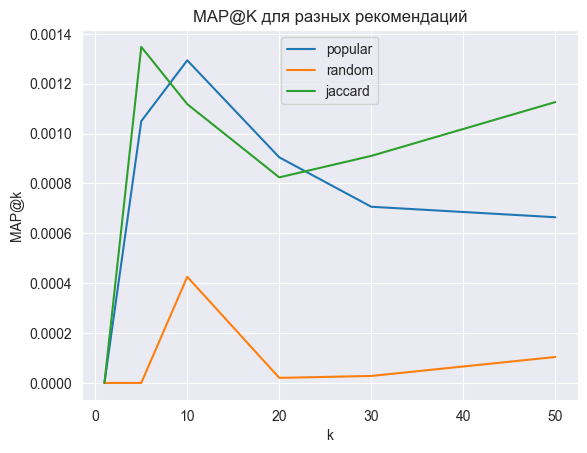

In [35]:
plt.plot(k_list, popular_mapk, label='popular')
plt.plot(k_list, random_mapk, label='random')
plt.plot(k_list, jaccard_mapk, label='jaccard')
plt.legend()
plt.title('MAP@K для разных рекомендаций')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.show()

При всех k наилучщий MAP@k получается при использовании рекомндаций на основе меры Жаккара

**Бонус (1 балла).** Как вы могли заметить, матрица оценок получается очень разреженной, но мы работаем с ней как с обычной, это не дело. Перепишите код так, чтобы все методы могли работать с разреженными матрицами и сравните скорость работы такого подхода с оригинальным.

In [ ]:
# your code here: ‿︵‿︵ヽ(°□° )ノ︵‿︵‿

Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [ ]:
user_id = np.random.randint(0, model.n_users)

In [ ]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
40,LoveGame,['Lady Gaga']
97,Heads Will Roll,['Yeah Yeah Yeahs']
160,Love Story,['Taylor Swift']
212,Let's Get It Started,['Black Eyed Peas']
230,Poison,['Bell Biv DeVoe']
254,Luxurious,['Gwen Stefani']
314,Get Ur Freak On,['Missy Elliott']
419,The Real Slim Shady,['Eminem']
427,My Name Is,['Eminem']
477,Bubble Pop Electric,"['Gwen Stefani', 'Johnny Vulture']"


In [ ]:
preds = model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

/tmp/ipykernel_44887/3482866136.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


Predicted tracks:


,name,artists
1073,Smells Like Teen Spirit,['Nirvana']
805,Zombie,['The Cranberries']
24500,Way Down We Go,['KALEO']
11493,The Show Must Go On,['Queen']
1019,It's My Life,['Bon Jovi']
8263,Shape Of My Heart,['Sting']
2555,Californication,['Red Hot Chili Peppers']
7533,Highway to Hell,['AC/DC']
33436,Believer,['Imagine Dragons']
14763,Seven Nation Army,['The White Stripes']


In [ ]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
67134,Завяжи,['EVASHA']
67156,Ghoul,['Twinky']
67167,Невеста,"['DOROFEEVA', 'Скриптонит']"
67216,all I want is you,"['Rebzyyx', 'hoshie star']"
67230,Enemy,"['Imagine Dragons', 'J.I.D', 'Arcane', 'League..."
67259,masquerade,['siouxxie sixxsta']
67307,I AM WOMAN,['Emmy Meli']


Получилось что модель порекомендавала очень популярные песни, хотя на самом деле пользователь слушает менее известные треки.

### Часть 2. Модель со скрытыми переменными: ALS

В этой части мы пощупаем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно.

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Заметьте, что описанная модель предназначена для работы только с __явной__ информацией. В нашем случае от модели будет требоваться всегда возвращать 1, так как мы считаем ошибку только по парам, о которых получили фидбек. Поэтому логично подумать, что постановка задачи не имеет смысла. Однако, на практике оказывается, что из-за случайности в инициализации матриц $P$ и $Q$, обученные векторы для всех треков и пользователей в конце обучения получаются разными. Поэтому модель все же не лишена смысла.

__P. P. S.__ Для более разумной работы с неявной информацией был предложен метод iALS, его описание можно найти в лекции. Ниже будет бонус на его реализацию.

**Задание 6 (0.5 балла).** На лекции рассматривались два подхода к оптимизации параметров. Можно это делать обычным стохастическим градинтным спуском, а можно по очереди обновлять матрицы $P, Q$, и тогда получится метод Alternating Least Squares (ALS). Выведите формулы обновления параметров для обоих методов.

**SGD:**  
для каждого наблюдения (u, i):  
$p_u := p_u - \eta (q_i(\langle p_u, q_i \rangle - r_{ui}) + λ p_u)$  
$q_i := q_i - \eta (p_u(\langle p_u, q_i \rangle - r_{ui}) + λ q_i)$  
**ALS:**  
$p_u = (\sum_{i:(u,i) \in R} q_i q_i^T + \lambda I)^{-1}(\sum_{i:(u,i) \in R}r_{ui}q_i)$  
$q_i = (\sum_{i:(u,i) \in R} q_i q_i^T + \lambda I)^{-1}(\sum_{i:(u,i) \in R}r_{ui}q_i)$


**Задание 7 (1.5 балла).** Реализуйте методы оптимизации параметров для обоих алгоритмов.

In [19]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd'):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003
        self.lamb = 0.01

        self.exist_R = np.argwhere(self.R == 1)

    def fit(self, num_iters=5):
        for epoch in tqdm(range(num_iters)):

            if self.mode == 'sgd':
                posible_pairs = self.exist_R.copy()
                np.random.shuffle(posible_pairs)
                loss = 0
                for u, i in posible_pairs:
                    old_p = self.P[u].copy()
                    self.P[u] -= self.lr * (self.Q[i] * (np.dot(self.P[u], self.Q[i]) - self.R[u, i]) + self.lamb * self.P[u])
                    self.Q[i] -= self.lr * (old_p * (np.dot(self.P[u], self.Q[i]) - self.R[u, i]) + self.lamb * self.Q[i])

            elif self.mode == 'als':
                for u in range(self.n_users):
                    existing_i = np.where(self.R[u, :] == 1)[0]
                    m = np.dot(self.Q[existing_i].T, self.Q[existing_i]) + self.lamb * np.identity(self.dim)
                    b = np.dot(self.Q[existing_i].T, self.R[u, existing_i])

                    self.P[u] = np.linalg.solve(m, b)

                for i in range(self.n_items):
                    existing_u = np.where(self.R[:, i] == 1)[0]
                    m = np.dot(self.P[existing_u].T, self.P[existing_u]) + self.lamb * np.identity(self.dim)
                    b = np.dot(self.P[existing_u].T, self.R[existing_u, i])

                    self.Q[i] = np.linalg.solve(m, b)

    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

**Задание 8 (1 балл).** Для обоих алгоритмов подберите оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$. Как изменяется качество предсказаний с числом итераций обучения? Постройте соответствующие графики, сравните со случайным подходом и User2User, сделайте выводы. Какой алгоритм вам кажется более подходящим для данной задачи и почему?

__P. S.__ Хотя бы один из методов обучения должен приводить к лучшим результатам в сравнении с User2User подходом.

__P. P. S.__ Методу SGD свойственно переобучаться, поэтому при подборе параметров полезно смотреть на значения ошибки и оптимизируемой метрики на тренировочном датасете. Вы также можете менять начальную инициализацию и прочие параметры, за исключением архитектуры, на ваш вкус.

In [21]:
dim_list = [10, 20 ,40, 60, 80, 100, 120, 150]

In [ ]:
dim_mapk_sgd = []
for dim in dim_list:
    np.random.seed(67)
    model = LatentFactorModel(train_ratings, dim)
    model.fit(20)
    test_recs = model.get_test_recommendations(10)
    dim_mapk_sgd.append(mapk(test_relevant, test_recs))

  0%|          | 0/20 [00:00<?, ?it/s]

0 8.376353565441198
1 5.546850102370224
2 4.180959011769318
3 3.369932158953556
4 2.8389305382793544
5 2.4681925435824685
6 2.1974555773061275
7 1.9928945187584288
8 1.83433111076092
9 1.7088786667663862
10 1.6078787697153392
11 1.5253736107425038
12 1.4571809548600299
13 1.4001745465479123
14 1.3520868761448033
15 1.3111327985833074
16 1.2760173309020653
17 1.2457092468967905
18 1.219351165116801
19 1.1963421430199872


  0%|          | 0/20 [00:00<?, ?it/s]

0 15.65501390083156
1 9.781385437006765
2 7.096478539313303
3 5.537205379319611
4 4.5225087511654785
5 3.814534062441017
6 3.2968144782831654
7 2.9051919030953814
8 2.601268583279433
9 2.360698252238012
10 2.167032467451997
11 2.009002394426696
12 1.8784407129328444
13 1.769444005826307
14 1.6776278930991766
15 1.5995877359254311
16 1.5327643747528525
17 1.475187286040375
18 1.4252158147581842
19 1.3815946948122486


  0%|          | 0/20 [00:00<?, ?it/s]

...

0 74.57808637668802
1 42.41847488004873
2 28.545128320218396
3 20.815813182709846
4 15.976908552156244
5 12.720271662177812
6 10.414423598744406
7 8.718388511769275
8 7.433203313749781
9 6.435615385967843
10 5.645661492959921
11 5.009740910978284
12 4.490175165524245
13 4.06048769288316
14 3.7010579176824168
15 3.3974410536755855
16 3.1387501120025174
17 2.916563154974305
18 2.7244122680735745
19 2.557256345699417


  0%|          | 0/20 [00:00<?, ?it/s]

0 88.9922342294839
1 49.61418643618082
2 32.909089069763255
3 23.745237927778163
4 18.07226968110683
5 14.287647328208847
6 11.627342182071622
7 9.681821227264058
8 8.214696923654914
9 7.080207335414578
10 6.1843205940517185
11 5.464645738759505
12 4.877825677685565
13 4.393069002676703
14 3.988064959383485
15 3.6463696897190285
16 3.355256033847436
17 3.105320094052828
18 2.889269107377459
19 2.7011125734725314


  0%|          | 0/20 [00:00<?, ?it/s]

0 110.7664263311373
1 60.15005713188892
2 39.20448863115076
3 27.890111152758166
4 20.973623944722952
5 16.40667851241079
6 13.22466402517666
7 10.9155959806895
8 9.185798868552947
9 7.856241089155812
10 6.811773388256924
11 5.976530868134891
12 5.298238313997019
13 4.739887200307684
14 4.274852248212315
15 3.8835491111972926
16 3.5511363746094746
17 3.2665065429708235
18 3.021085693557742
19 2.807959110135039


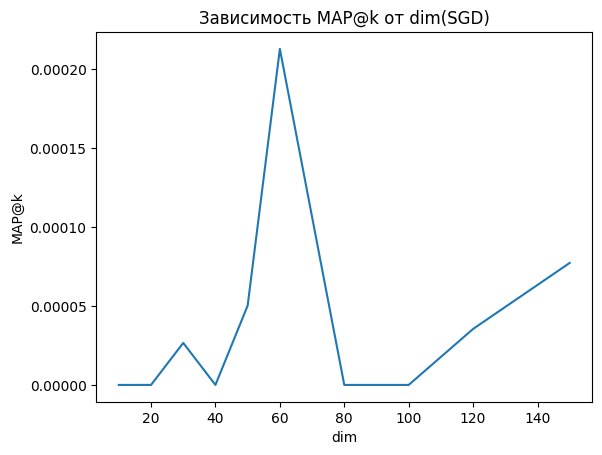

In [ ]:
plt.plot(dim_list, dim_mapk_sgd)
plt.title('Зависимость MAP@k от dim(SGD)')
plt.xlabel('dim')
plt.ylabel('MAP@k')
plt.show()

In [ ]:
best_dim_sgd = dim_list[np.argmax(dim_mapk_sgd)]

In [ ]:
k_mapk_sgd = []
for k in k_list:
    np.random.seed(67)
    model = LatentFactorModel(train_ratings, best_dim_sgd)
    model.fit(10)
    test_recs = model.get_test_recommendations(k)
    k_mapk_sgd.append(mapk(test_relevant, test_recs))

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

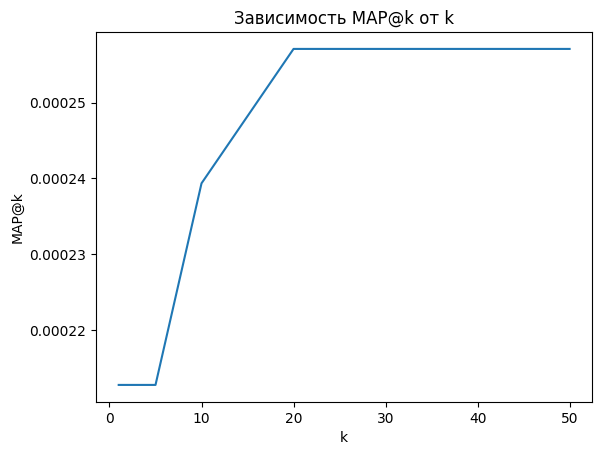

In [ ]:
plt.plot(k_list, k_mapk_sgd)
plt.title('Зависимость MAP@k от k(SGD)')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.show()

In [22]:
dim_mapk_als = []
for dim in dim_list:
    np.random.seed(67)
    model = LatentFactorModel(train_ratings, dim, 'als')
    model.fit(5)
    test_recs = model.get_test_recommendations(10)
    dim_mapk_als.append(mapk(test_relevant, test_recs))

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

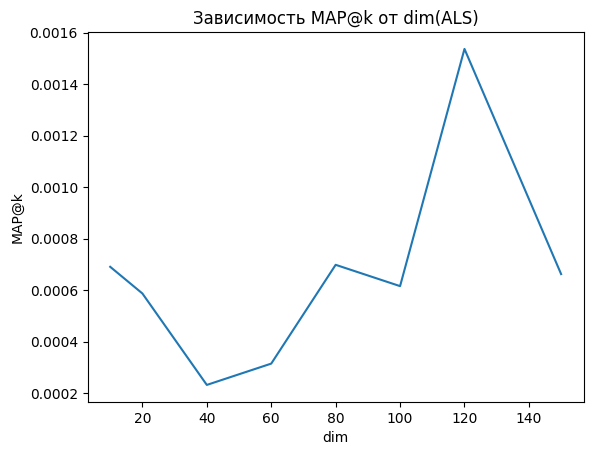

In [23]:
plt.plot(dim_list, dim_mapk_als)
plt.title('Зависимость MAP@k от dim(ALS)')
plt.xlabel('dim')
plt.ylabel('MAP@k')
plt.show()

In [24]:
best_dim_als = dim_list[np.argmax(dim_mapk_als)]

In [26]:
k_mapk_als = []
for k in k_list:
    np.random.seed(67)
    model = LatentFactorModel(train_ratings, best_dim_als, 'als')
    model.fit(5)
    test_recs = model.get_test_recommendations(k)
    k_mapk_als.append(mapk(test_relevant, test_recs))

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

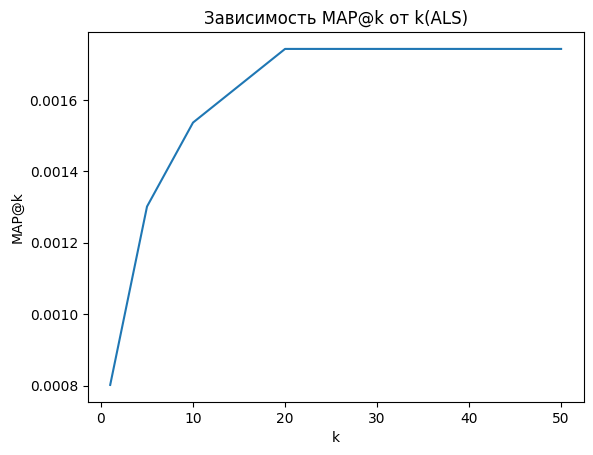

In [27]:
plt.plot(k_list, k_mapk_als)
plt.title('Зависимость MAP@k от k(ALS)')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.show()

Если у вас получилось достаточно хорошее качество, то при оптимизации параметров марицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степерь обученности модели вручную.

In [ ]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

preds = model.Q @ model.Q[example_trackId]
preds = preds / np.sqrt((model.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

In [ ]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(model.Q[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
2058,Последний герой,['КИНО'],0.714396
26075,Лошадка,['Найк Борзов'],0.598309
2857,Empty Walls,['Serj Tankian'],0.584627
17331,"Последнее письмо (Гудбай, Америка)",['Nautilus Pompilius'],0.569852
9689,Bicycle Race,['Queen'],0.569107
16637,Zodiac,['Zodiac'],0.569107
5153,Stormbringer,['Deep Purple'],0.569107
2179,Восьмиклассница,['КИНО'],0.553157
14871,Никто не услышит (Ой-йо),['ЧайФ'],0.552117


**Бонус (1.5 балла).**

Постройте модель iALS и сравните ее качество с обучением ALS и SGD.

In [ ]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

### Часть 3. Второй уровень рекомендаций.

Выше мы построили простейшие модели, которые показывают не слишком высокое качество, но зато работают очень быстро. Воспользуемся ими для того, чтобы отобрать некоторое количество наиболее перспективных треков, которые мы сможем отранжировать уже более сложной моделью (в нашем случае это будет [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

**Задание 9 (1 балл).**

Для каждого пользователя возьмите топ-100 рекомендованных треков от модели LFM (ALS или SGD на ваш выбор) и топ-100 от модели User2User. Это будут наши кандидаты, которые мы затем будем ранжировать бустингом.

In [37]:
model_user = User2User(train_ratings)
jaccard_recs = model_user.get_test_recommendations(100)

np.random.seed(67)
model_lfm = LatentFactorModel(train_ratings, best_dim_als, 'als')
model_lfm.fit(5)
lfm_recs = model_lfm.get_test_recommendations(100)

  0%|          | 0/5 [00:00<?, ?it/s]

**Задание 10 (2 балла).**

Подготовьте датасет для обучения модели ранжирования. Он должен состоять из пар: объект, целевая переменная. Объект - это пара (user, item) и всякие дополнительные признаки на их основе. Предлагается создать набор следующих признаков, однако вы можете добавлять свои по желанию, если они вам кажутся разумными:
 1) id пользователя
 1) id трека
 1) косинусное расстояние между эмбеддингами LFM соответствующих пользователя и трека
 1) среднее значение меры Жаккара между этим пользователем и остальными из User2User модели
 1) доля пользователей, слушавших этот трек (взять из обучающей выборки в Части 1)
 1) количество прослушанных пользователем треков (взять из обучающей выборки в Части 1)

В качестве целевой переменной возьмем бинарную метку "попал ли трек в 50 последних прослушанных пользователем"

Разбейте полученную выборку на обучающую и тестовую в отношении 3:2 так, чтобы пропорции положительных и отрицательных примеров в обоих подвыборках были одинаковыми.

In [38]:
data = set()
for u in range(len(jaccard_recs)):
    for i in jaccard_recs[u]:
        data.add((u, i))

for u in range(len(lfm_recs)):
    for i in lfm_recs[u]:
        data.add((u, i))

new_data = pd.DataFrame(data, columns=['user_id', 'track_id'])

In [ ]:
cos_dist = []
avg_jaccar = []
for u, i in data:
    cos_dist.append(cosine(model_lfm.P[u], model_lfm.Q[i]))
    sims = model_user.similarity(model_user.R[u])
    sims[u] = 0
    avg_jaccar.append(np.mean(sims))

new_data['cosin_dist'] = pd.Series(cos_dist)
new_data['avg_jaccar'] = pd.Series(avg_jaccar)

Как уже было сказано, для построения ранжирующей модели мы будем пользоваться библиотекой [CatBoost](https://www.youtube.com/watch?v=X1-MXdyThJ0).

Для преобразования датасета в удобный вид полезно использовать метод [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool).

In [ ]:
import catboost

# group_id == user_id here
train_pool = catboost.Pool(X_train, y_train, group_id=train_group_id)
test_pool = catboost.Pool(X_test, y_test, group_id=test_group_id)

**Задание 11 (1 балл)**

Обучите `CatBoostClassifier`. С его помощью сделайте предсказания для тестовой выборки и посчитайте MAP@20. Сравните с рекомендациями моделей User2User и LFM. Учтите, что для честного сравнения необходимо пересчитать предсказания моделей на нашей новой тестовой выборке. Получилось ли улучшить результаты?

In [ ]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

**Задание 12 (1 балл)**

Обучите `CatBoostRanker`, выбрав подходящую функцию ранжирования из тех, которые были рассмотрены на лекции. Проделайте все те же действия, что и с `CatBoostClassifier` и сравните результаты.

In [ ]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪